In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
import os

# Unzip the titanic.zip file
!unzip -o /content/titanic.zip -d /content/

# Check for the unzipped file, assuming it's directly in /content/
# and rename it if needed, or simply read it directly if the name is correct.
# Let's assume train.csv is directly available after unzipping to /content/
df = pd.read_csv("/content/train.csv")

df.head()

Archive:  /content/titanic.zip
  inflating: /content/gender_submission.csv  
  inflating: /content/test.csv       
  inflating: /content/train.csv      


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.shape

(891, 12)

In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [9]:
df['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [10]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [11]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [12]:
df.duplicated().sum()

np.int64(0)

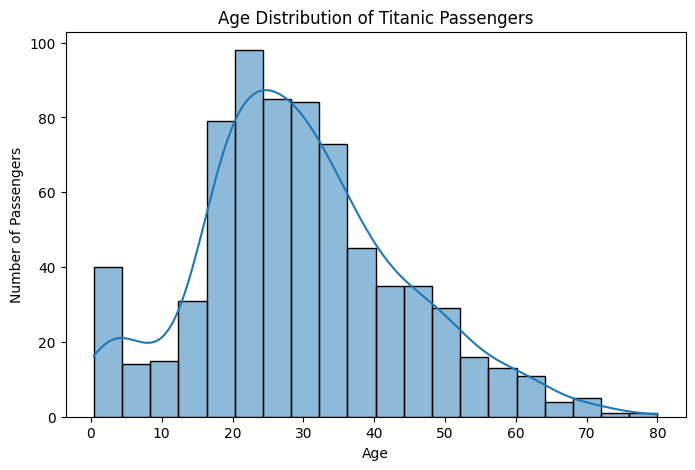

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'].dropna(), bins=20, kde=True)

plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

plt.show()

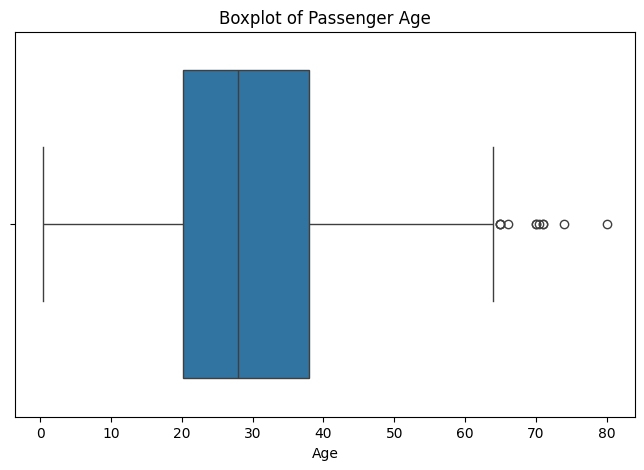

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Age'])

plt.title('Boxplot of Passenger Age')
plt.xlabel('Age')

plt.show()

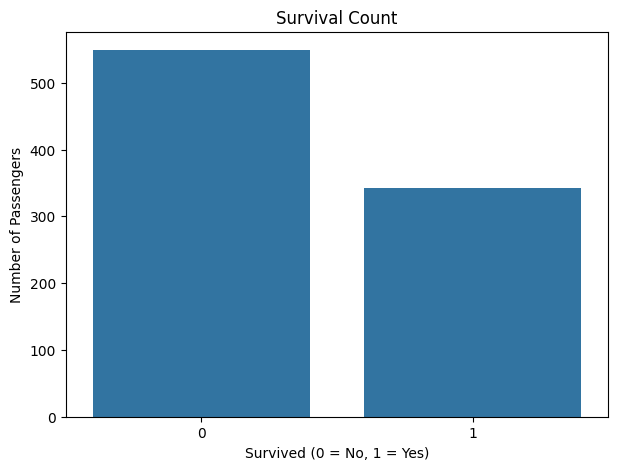

In [15]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='Survived')

plt.title('Survival Count')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')

plt.show()

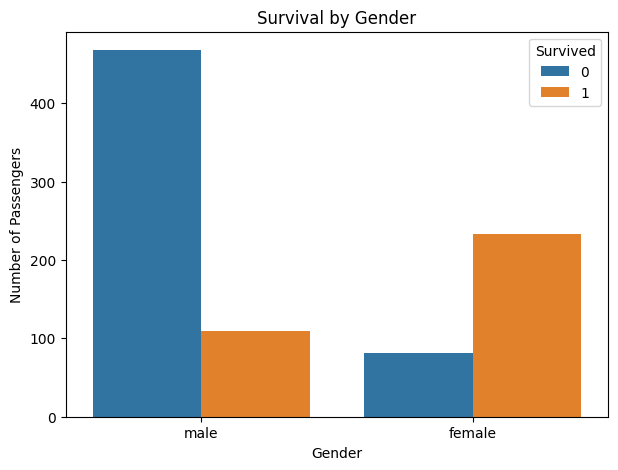

In [16]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='Sex', hue='Survived')

plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')

plt.show()

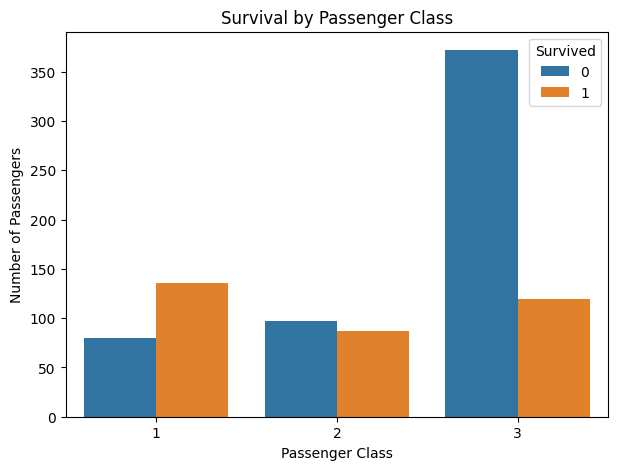

In [17]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='Pclass', hue='Survived')

plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')

plt.show()

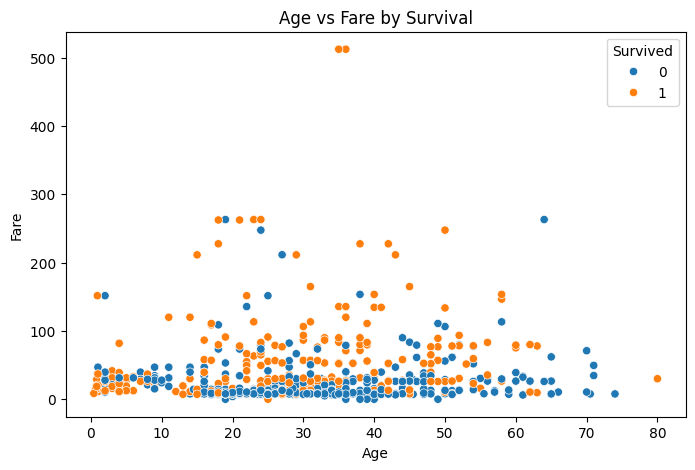

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Age',
    y='Fare',
    hue='Survived'
)

plt.title('Age vs Fare by Survival')
plt.xlabel('Age')
plt.ylabel('Fare')

plt.show()

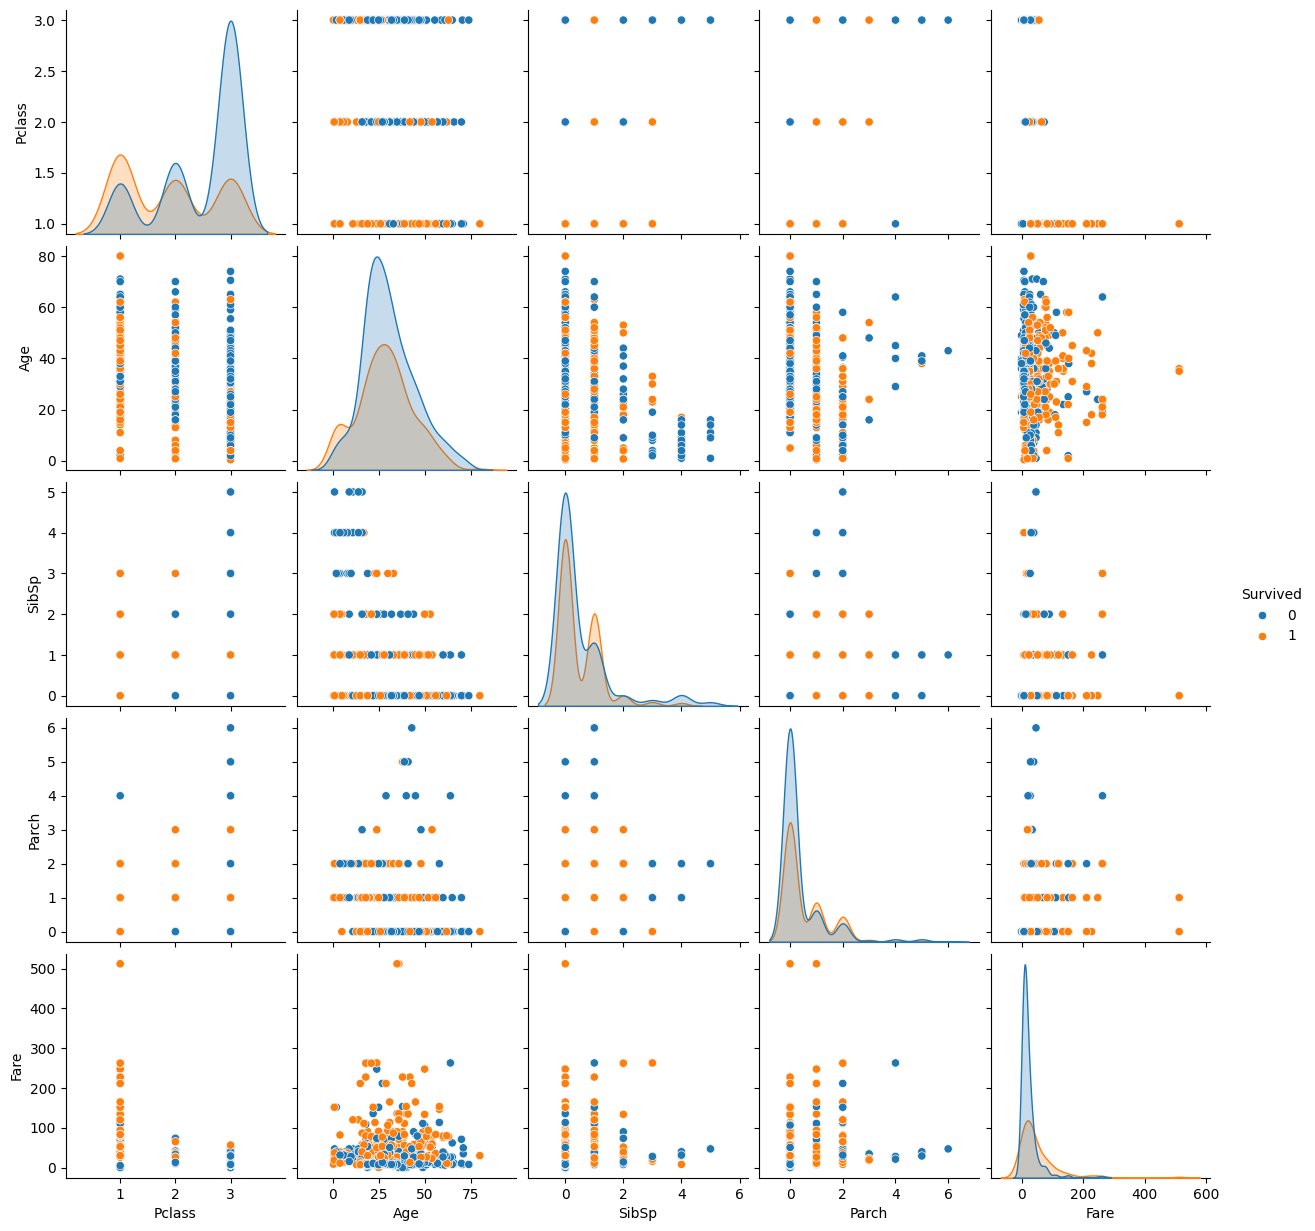

In [19]:
sns.pairplot(
    df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].dropna(),
    hue='Survived'
)

plt.show()

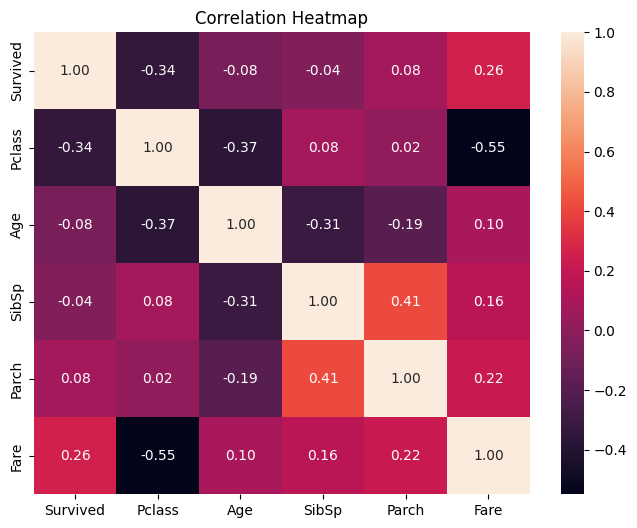

In [20]:
plt.figure(figsize=(8,6))

corr = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr()

sns.heatmap(corr, annot=True, fmt='.2f')

plt.title('Correlation Heatmap')

plt.show()

In [21]:
print("Survival rate by gender:")
print(df.groupby('Sex')['Survived'].mean())

print("\nSurvival rate by passenger class:")
print(df.groupby('Pclass')['Survived'].mean())

Survival rate by gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival rate by passenger class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


## Conclusion

The Exploratory Data Analysis of the Titanic dataset revealed several important patterns. Female passengers generally had a higher survival rate than male passengers. Passenger class was also strongly associated with survival, with passengers in higher classes generally having better survival outcomes.

The analysis also showed relationships between fare and passenger class. Histograms and boxplots helped understand the distribution of age and identify possible outliers. Scatterplots, pairplots, and correlation heatmaps helped identify relationships between different numerical variables.

Overall, the EDA demonstrates how statistical analysis and visualization can be used to discover meaningful patterns and trends in a real-world dataset.